In [2]:
import cv2
import iris
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import os
from pathlib import Path
from tqdm import tqdm
from itertools import combinations
import random
from PIL import Image

# Effect of pre-segmentation image downsampling on IrisPipeline execution speed (CASIA dataset)

In [ ]:
img_path = "archive/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L00.jpg"
test_path = "archive/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L06.jpg"
img = Image.open(img_path)
test_img = Image.open(test_path)

In [32]:
def get_execution_time(img_pixels):
    ir_image = iris.IRImage(img_data=img_pixels, image_id="example", eye_side="left")
    pipeline = iris.IRISPipeline()
    start_time = time.perf_counter()
    
    output = pipeline(ir_image)
    
    end_time = time.perf_counter()
    return end_time - start_time

In [33]:
downsampling_ratios = [0.1 * x for x in range(10, 31)] # 1.0 to 3.0
execution_times = []

for ratio in downsampling_ratios:
    downsampled = img.resize((int(img.size[0] // ratio), int(img.size[1] // ratio)), resample=Image.LANCZOS) # uses the Lanczos algorithm
    grey_img = downsampled.convert('L')
    img_pixels = np.array(grey_img)

    exe_time = get_execution_time(img_pixels)
    execution_times.append(exe_time)


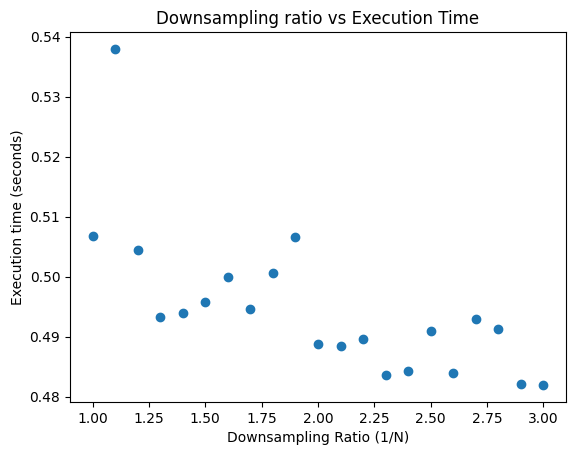

In [34]:
plt.scatter(downsampling_ratios, execution_times, marker='o')
plt.title('Downsampling ratio vs Execution Time')
plt.xlabel('Downsampling Ratio (1/N)')
plt.ylabel('Execution time (seconds)')
plt.show()

# Effect of pre-segmentation image downsampling on recognition accuracy (CASIA dataset)

Conclusion: Significant loss of information leading to lower recognition accuracy is not seen on CASIA dataset images (640x480 pixels) until the image is downsampled by a factor greater than 3.5. Thus, if computational performance is a high priority, one can downsample images prior to inference without appreciably sacrificing accuracy.

In [24]:
def calc_template(img_pixels):
    iris_pipeline = iris.IRISPipeline()
    output = iris_pipeline(
        iris.IRImage(
            img_data=img_pixels,
            image_id=os.path.basename(img_path),
            eye_side='left'
        )
    )
    return output["iris_template"] 

In [28]:
test_template = calc_template(np.array(test_img))
matcher = iris.HammingDistanceMatcher()
downsampling_ratios = [0.1 * x for x in range(10, 41)] # 1.0 to 2.9
ham_distances = {}
for ratio in downsampling_ratios:
    downsampled = img.resize((int(img.size[0] // ratio), int(img.size[1] // ratio)), resample=Image.LANCZOS)
    grey_img = downsampled.convert('L')
    img_pixels = np.array(grey_img)
    template = calc_template(img_pixels)
    if template is not None:  
        ham_distance = matcher.run(template, test_template)
        ham_distances[ratio] = ham_distance

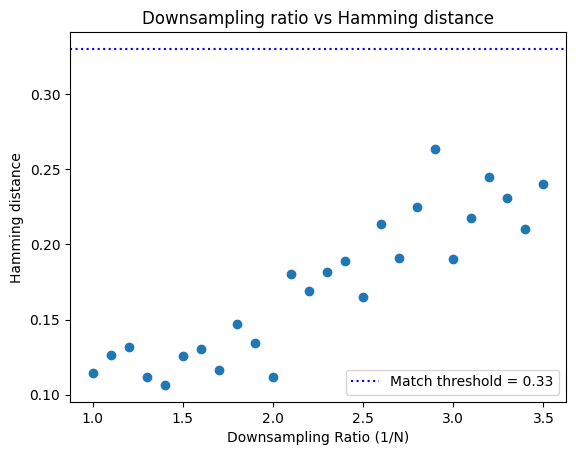

In [30]:
plt.scatter(ham_distances.keys(), ham_distances.values())
plt.title("Downsampling ratio vs Hamming distance")
plt.axhline(y=0.33, color='blue', linestyle=':', label='Match threshold = 0.33')
plt.xlabel('Downsampling Ratio (1/N)')
plt.ylabel('Hamming distance')
plt.legend()
plt.show()